# 🌸 Iris Flower Classification — Data Science Internship Project

## Objective
Classify Iris flower species (*setosa, versicolor, virginica*) using Machine Learning models based on flower measurements.

### Dataset
- UCI Iris Dataset (loaded from scikit-learn)

### Models Used
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

In [1]:
# ============================================
# IMPORTS & SETUP
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================
# LOAD DATASET
# ============================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, target_names)

print("Dataset Loaded Successfully")
print("\nDataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# ============================================
# DATASET INFORMATION
# ============================================

print("Feature Names:")
print(feature_names)

print("\nTarget Classes:")
print(target_names)

print("\nClass Distribution:")
print(df["species"].value_counts())

print("\nStatistical Summary:")
display(df.describe().round(2))

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


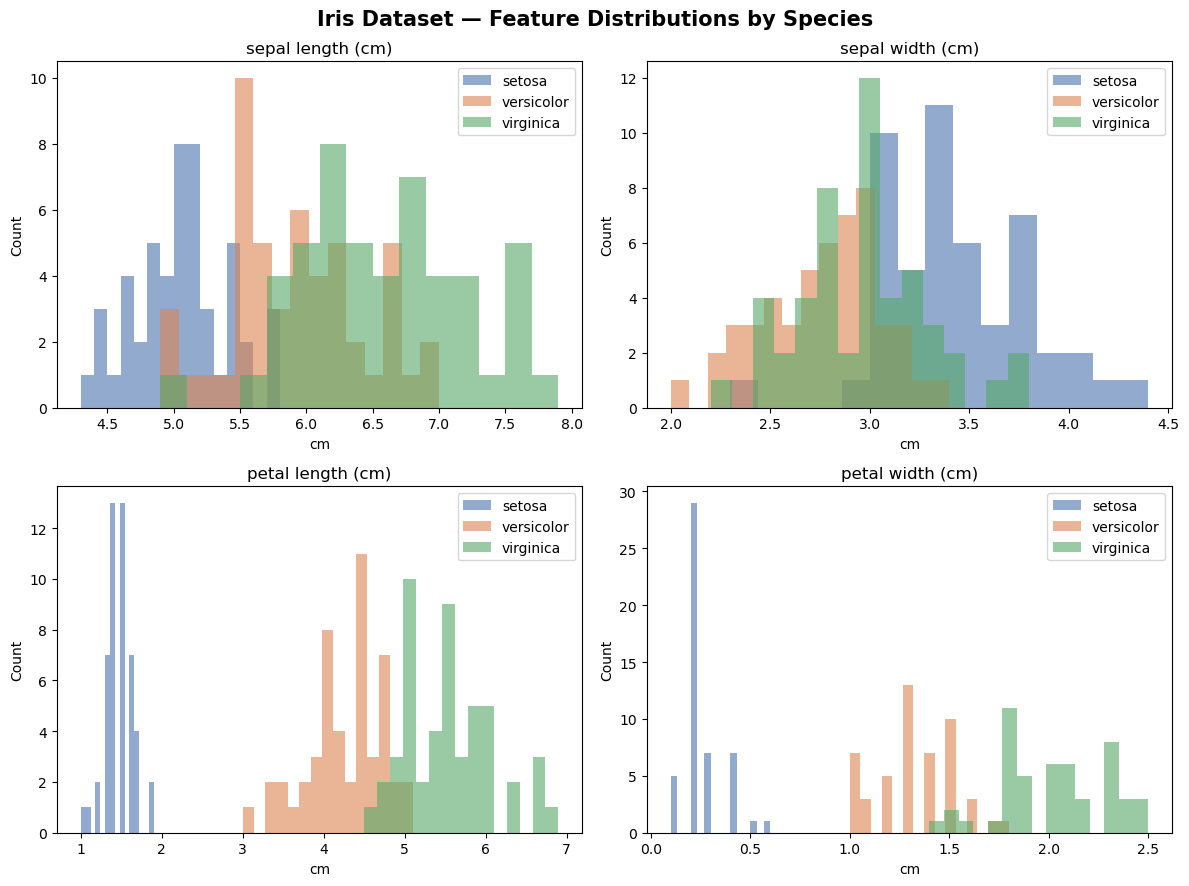

In [4]:
# ============================================
# FEATURE DISTRIBUTIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

fig.suptitle(
    "Iris Dataset — Feature Distributions by Species",
    fontsize=15,
    fontweight="bold"
)

colors = {
    "setosa": "#4C72B0",
    "versicolor": "#DD8452",
    "virginica": "#55A868"
}

for ax, feat in zip(axes.flatten(), feature_names):

    for species in target_names:
        data = df[df["species"] == species][feat]

        ax.hist(
            data,
            bins=15,
            alpha=0.6,
            label=species,
            color=colors[species]
        )

    ax.set_title(feat)
    ax.set_xlabel("cm")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

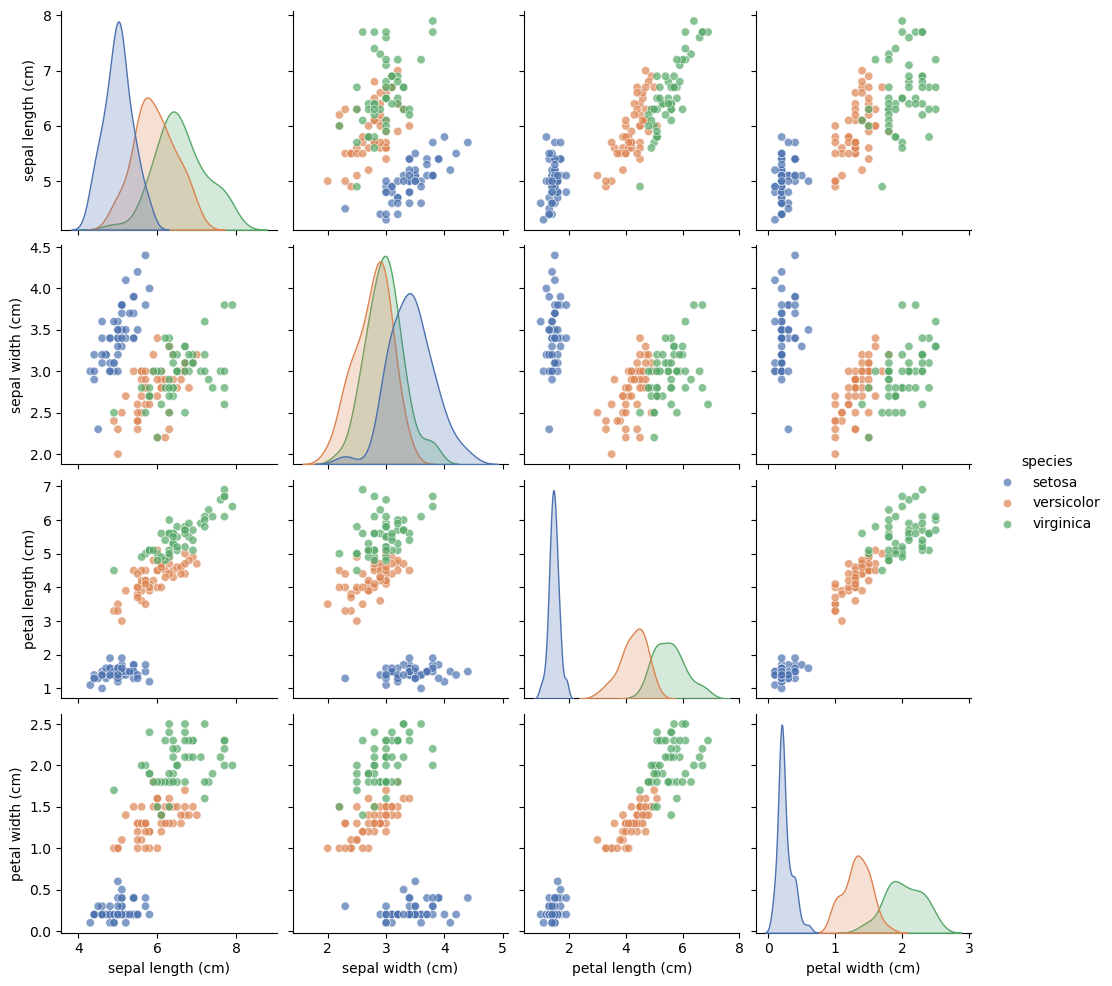

In [5]:
# ============================================
# PAIR PLOT
# ============================================

sns.pairplot(
    df,
    hue="species",
    palette=colors,
    plot_kws=dict(alpha=0.7)
)

plt.show()

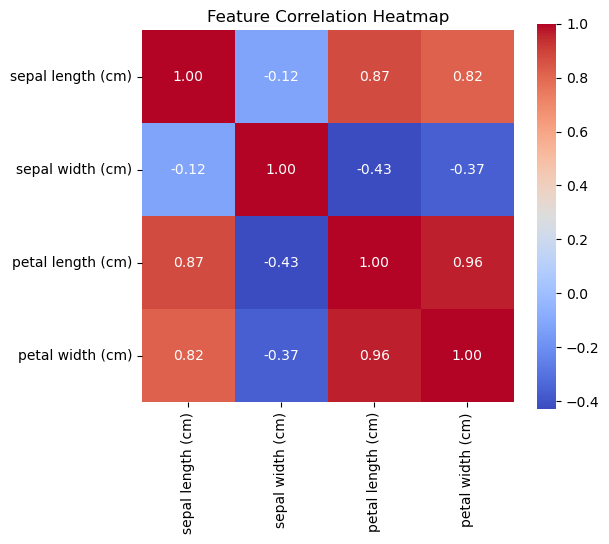

In [6]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(6, 5))

corr = df[feature_names].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 120
Testing Samples : 30


In [8]:
# ============================================
# DEFINE MACHINE LEARNING MODELS
# ============================================

models = {

    "Logistic Regression":
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, random_state=42))
    ]),

    "K-Nearest Neighbors":
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Support Vector Machine":
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", random_state=42))
    ]),

    "Decision Tree":
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),

    "Random Forest":
    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            random_state=42
        ))
    ])
}

print("Models created successfully.")

Models created successfully.


In [9]:
# ============================================
# TRAINING & EVALUATION
# ============================================

results = {}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"{'Model':<26} {'Test Acc':>10} {'CV Mean':>10}")

for name, pipeline in models.items():

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Accuracy
    test_acc = accuracy_score(y_test, y_pred)

    # Cross Validation
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    results[name] = {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "test_acc": test_acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

    print(
        f"{name:<26} "
        f"{test_acc*100:>8.2f}% "
        f"{cv_scores.mean()*100:>8.2f}%"
    )

Model                        Test Acc    CV Mean
Logistic Regression           93.33%    95.33%
K-Nearest Neighbors           93.33%    97.33%
Support Vector Machine        96.67%    96.00%
Decision Tree                 93.33%    95.33%
Random Forest                 96.67%    96.00%


In [10]:
# ============================================
# BEST MODEL REPORT
# ============================================

best_name = max(results, key=lambda n: results[n]["cv_mean"])

best = results[best_name]

print("Best Model:", best_name)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best["y_pred"],
        target_names=target_names
    )
)

Best Model: K-Nearest Neighbors

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



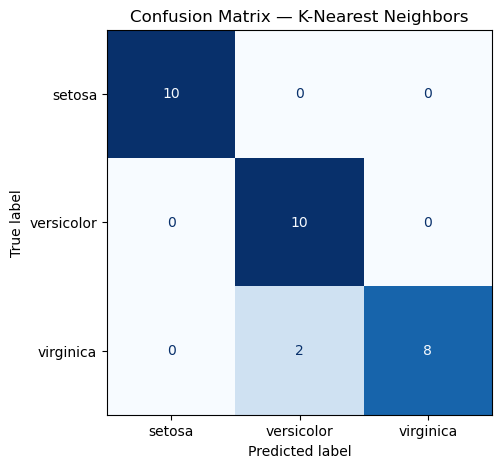

In [11]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, best["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title(f"Confusion Matrix — {best_name}")

plt.show()

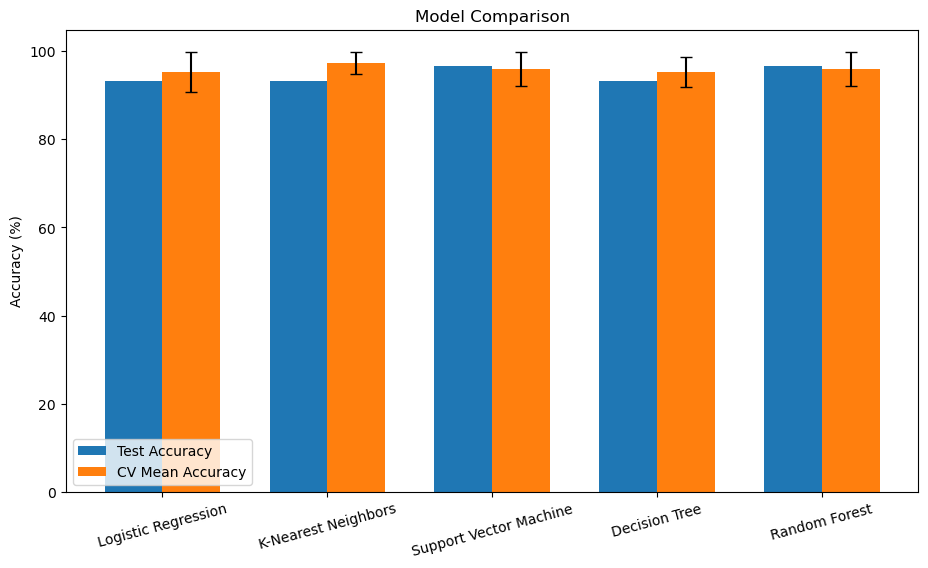

In [12]:
# ============================================
# MODEL COMPARISON
# ============================================

names = list(results.keys())

cv_means = [results[n]["cv_mean"] * 100 for n in names]
cv_stds = [results[n]["cv_std"] * 100 for n in names]

test_acc = [results[n]["test_acc"] * 100 for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    test_acc,
    width,
    label="Test Accuracy"
)

bars2 = ax.bar(
    x + width/2,
    cv_means,
    width,
    label="CV Mean Accuracy",
    yerr=cv_stds,
    capsize=4
)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)

ax.set_ylabel("Accuracy (%)")

ax.set_title("Model Comparison")

ax.legend()

plt.show()

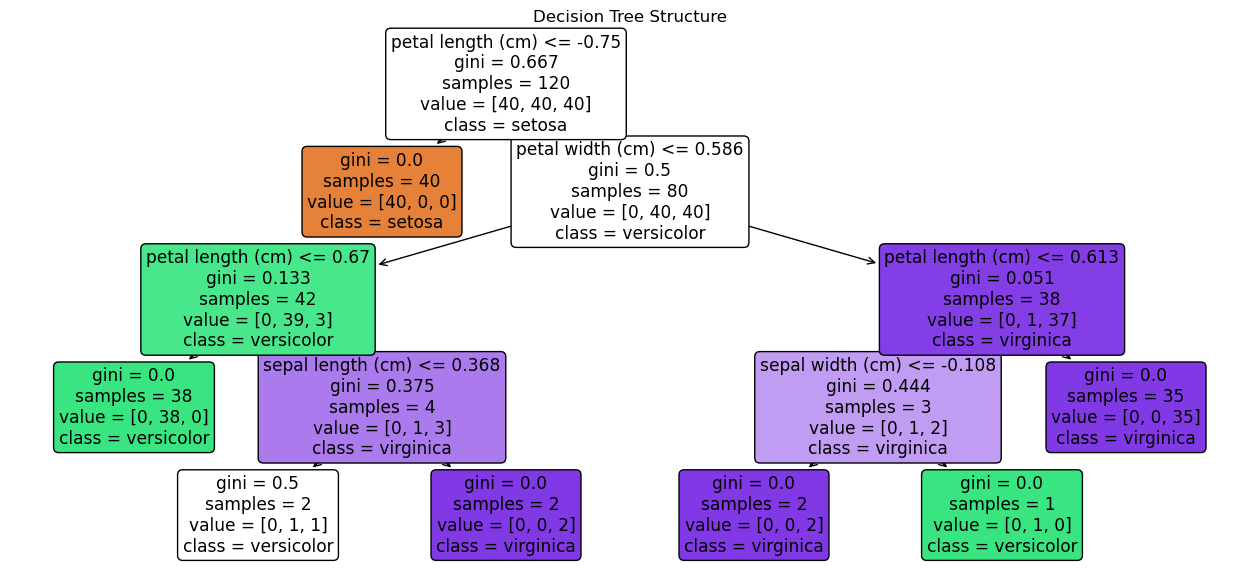

In [13]:
# ============================================
# DECISION TREE VISUALIZATION
# ============================================

dt_pipeline = models["Decision Tree"]

dt_clf = dt_pipeline.named_steps["clf"]

plt.figure(figsize=(16, 7))

plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Structure")

plt.show()

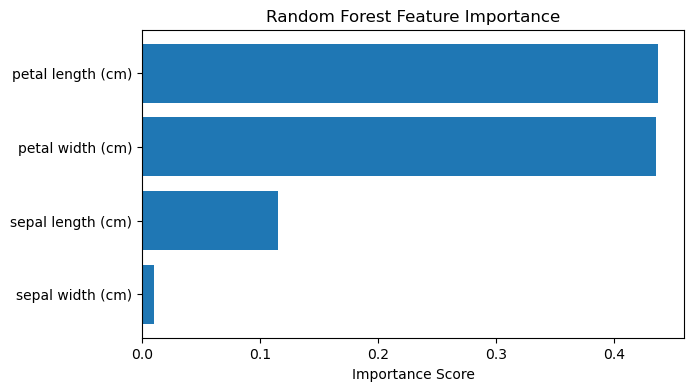

In [14]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

rf_clf = models["Random Forest"].named_steps["clf"]

importances = rf_clf.feature_importances_

sorted_idx = np.argsort(importances)[::-1]

sorted_feats = [feature_names[i] for i in sorted_idx]
sorted_imps = importances[sorted_idx]

plt.figure(figsize=(7, 4))

plt.barh(sorted_feats[::-1], sorted_imps[::-1])

plt.xlabel("Importance Score")

plt.title("Random Forest Feature Importance")

plt.show()

In [15]:
# ============================================
# PREDICT NEW SAMPLE
# ============================================

sample = np.array([[5.1, 3.5, 1.4, 0.2]])

print("Predictions for Sample:\n")

for name, res in results.items():

    pred = res["pipeline"].predict(sample)[0]

    print(f"{name:<26} → {target_names[pred]}")

Predictions for Sample:

Logistic Regression        → setosa
K-Nearest Neighbors        → setosa
Support Vector Machine     → setosa
Decision Tree              → setosa
Random Forest              → setosa


In [16]:
# ============================================
# FINAL SUMMARY
# ============================================

print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)

print(f"\nBest Model      : {best_name}")

print(
    f"Test Accuracy   : "
    f"{best['test_acc']*100:.2f}%"
)

print(
    f"CV Accuracy     : "
    f"{best['cv_mean']*100:.2f}% "
    f"± {best['cv_std']*100:.2f}%"
)

print("\nProject Completed Successfully ✓")

PROJECT SUMMARY

Best Model      : K-Nearest Neighbors
Test Accuracy   : 93.33%
CV Accuracy     : 97.33% ± 2.49%

Project Completed Successfully ✓
